# Tarefa: PCA e Árvore de Decisão — Seleção de Atributos vs. Redução de Dimensionalidade

**Aluno:** Cauê Reis

**Disciplina:** Mineração de Dados

## Dataset Iris — Importância de Atributos (Decision Tree) e Redução de Dimensionalidade (PCA)

**Objetivo:** Comparar como uma Árvore de Decisão identifica a importância direta de cada atributo e como o PCA sintetiza esses mesmos atributos em novos componentes. Aplica-se Análise de Componentes Principais (PCA) para reduzir a dimensionalidade e o modelo de Árvore de Decisão para seleção de atributos relevantes no dataset Iris (sklearn), que possui 4 atributos e 150 amostras.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

### 1. Carregamento dos Dados

In [3]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['Especie'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print('Primeiras observacoes do dataset:')
display(df.head(10))

print(f'\nDimensoes: {df.shape[0]} amostras x {df.shape[1]-2} atributos')
print(f'Classes   : {list(iris.target_names)}')
print(f'\nDistribuicao das classes:')
print(df['Especie'].value_counts())

Primeiras observacoes do dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Especie
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa



Dimensoes: 150 amostras x 4 atributos
Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Distribuicao das classes:
Especie
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### 2. Análise Exploratória dos Dados

In [5]:
display(df[iris.feature_names].describe().round(3))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


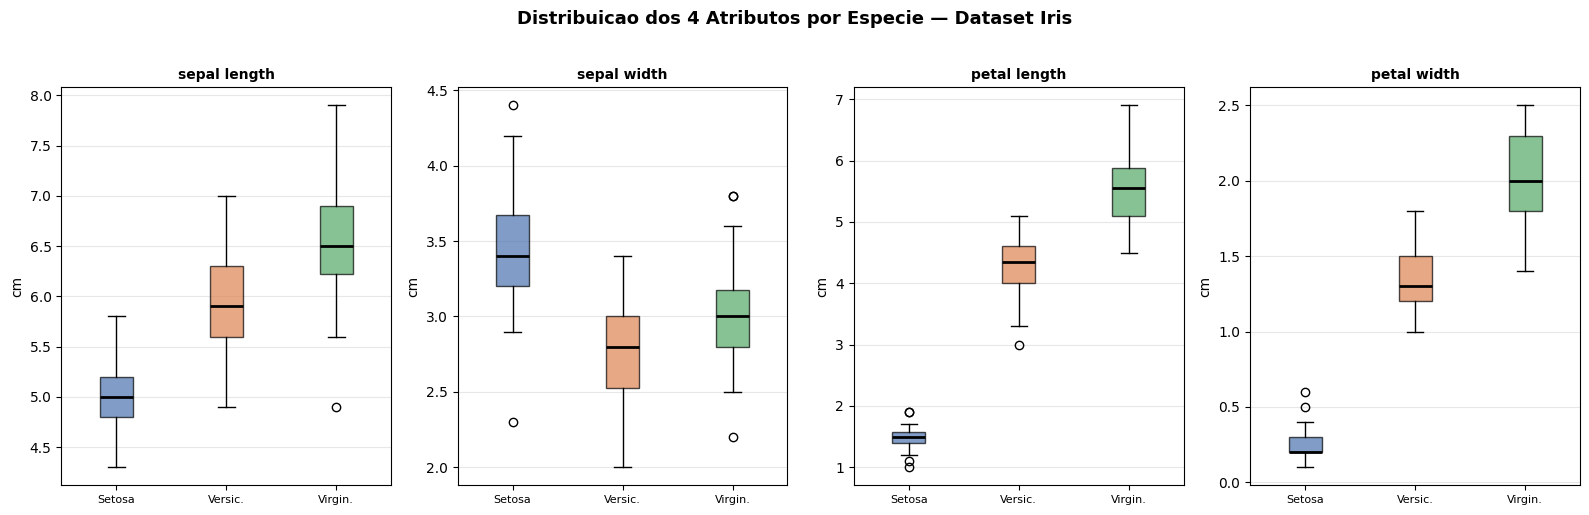

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

cores = {'Setosa': '#4C72B0', 'Versicolor': '#DD8452', 'Virginica': '#55A868'}

for ax, feature in zip(axes, iris.feature_names):
    grupos = [df[df['Especie'] == esp][feature].values for esp in cores]
    bp = ax.boxplot(grupos, patch_artist=True)
    for patch, cor in zip(bp['boxes'], cores.values()):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    ax.set_title(feature.replace(' (cm)', ''), fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Setosa', 'Versic.', 'Virgin.'], fontsize=8)
    ax.set_ylabel('cm')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribuicao dos 4 Atributos por Especie — Dataset Iris',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

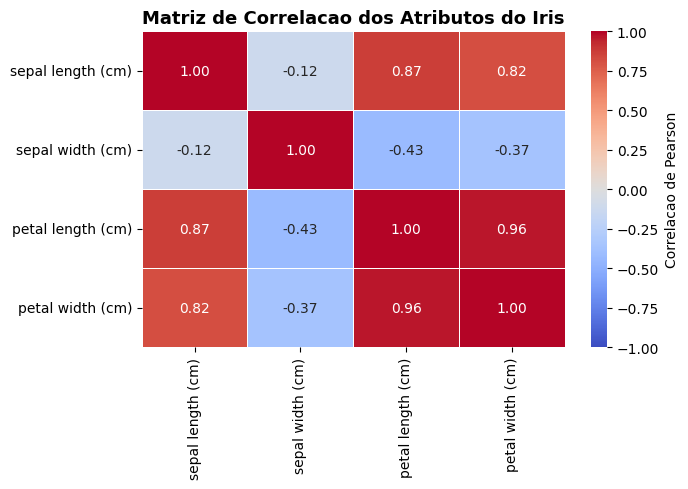

In [8]:
corr_matrix = df[iris.feature_names].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'label': 'Correlacao de Pearson'}
)
plt.title('Matriz de Correlacao dos Atributos do Iris', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Pré-processamento — Padronização dos Dados

In [9]:
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dados originais (primeiras 3 linhas):')
print(pd.DataFrame(X[:3], columns=iris.feature_names).round(3).to_string())
print()
print('Dados padronizados (primeiras 3 linhas):')
print(pd.DataFrame(X_scaled[:3], columns=iris.feature_names).round(3).to_string())
print()
print(f'Media pos-escala (deve ser ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Desvio pos-escala (deve ser ~1): {X_scaled.std(axis=0).round(6)}')

Dados originais (primeiras 3 linhas):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2

Dados padronizados (primeiras 3 linhas):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0             -0.901             1.019             -1.340            -1.315
1             -1.143            -0.132             -1.340            -1.315
2             -1.385             0.328             -1.397            -1.315

Media pos-escala (deve ser ~0): [-0. -0. -0. -0.]
Desvio pos-escala (deve ser ~1): [1. 1. 1. 1.]


### 4. Árvore de Decisão — Seleção de Atributos por Importância

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

importancias = dt.feature_importances_
nomes_atributos = ['sepal length', 'sepal width', 'petal length', 'petal width']

df_import = pd.DataFrame({
    'Atributo': nomes_atributos,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

y_pred = dt.predict(X_test)
print(f'Acuracia da Arvore de Decisao no conjunto de teste: {accuracy_score(y_test, y_pred)*100:.1f}%')
print()
print('Importancia de cada atributo (Gini Impurity):')
print(df_import.to_string(index=False))

Acuracia da Arvore de Decisao no conjunto de teste: 88.9%

Importancia de cada atributo (Gini Impurity):
    Atributo  Importancia
petal length     0.549020
 petal width     0.436488
 sepal width     0.014493
sepal length     0.000000


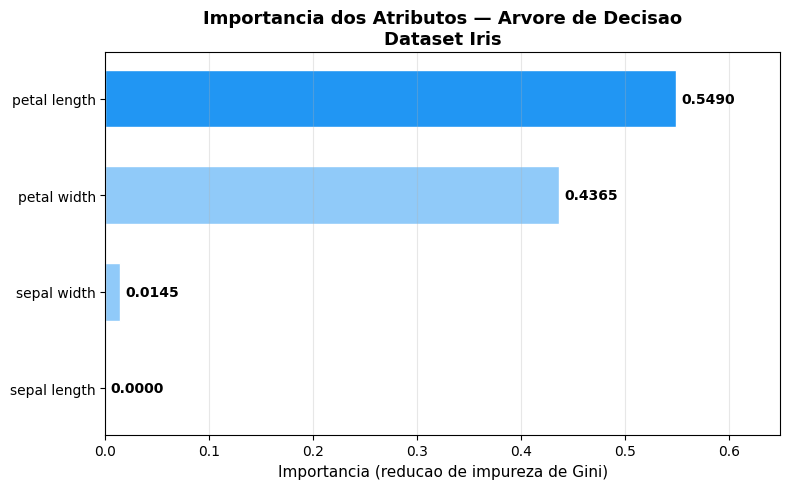

In [11]:
cores_barras = ['#2196F3' if i == 0 else '#90CAF9' for i in range(len(df_import))]

plt.figure(figsize=(8, 5))
bars = plt.barh(
    df_import['Atributo'], df_import['Importancia'],
    color=cores_barras, edgecolor='white', height=0.6
)

for bar, val in zip(bars, df_import['Importancia']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Importancia (reducao de impureza de Gini)', fontsize=11)
plt.title('Importancia dos Atributos — Arvore de Decisao\nDataset Iris',
          fontsize=13, fontweight='bold')
plt.xlim(0, df_import['Importancia'].max() + 0.1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

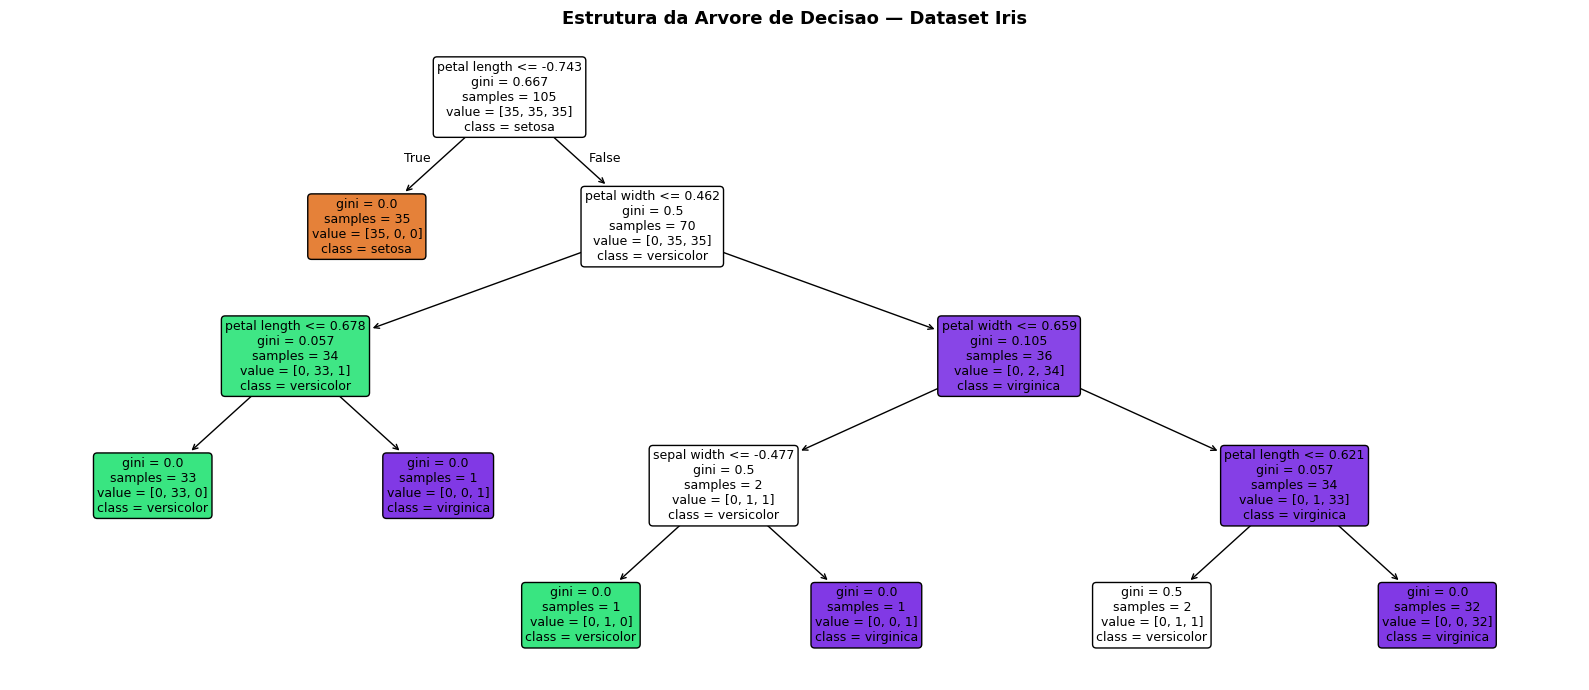

In [12]:
plt.figure(figsize=(16, 7))
plot_tree(
    dt,
    feature_names=nomes_atributos,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=9
)
plt.title('Estrutura da Arvore de Decisao — Dataset Iris', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. PCA — Análise de Componentes Principais

In [13]:
pca_full = PCA(n_components=4, random_state=42)
pca_full.fit(X_scaled)

variancia_explicada = pca_full.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

df_pca_info = pd.DataFrame({
    'Componente'         : [f'PC{i+1}' for i in range(4)],
    'Variancia Expl. (%)': (variancia_explicada * 100).round(2),
    'Variancia Acum. (%)': (variancia_acumulada  * 100).round(2)
})

print('Variancia explicada por componente:')
print(df_pca_info.to_string(index=False))

Variancia explicada por componente:
Componente  Variancia Expl. (%)  Variancia Acum. (%)
       PC1                72.96                72.96
       PC2                22.85                95.81
       PC3                 3.67                99.48
       PC4                 0.52               100.00


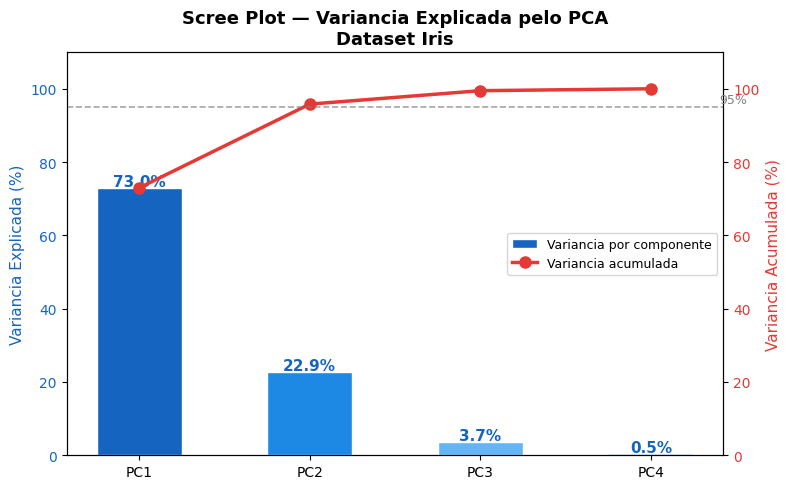

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 5))
componentes = [f'PC{i+1}' for i in range(4)]

bars = ax1.bar(
    componentes, variancia_explicada * 100,
    color=['#1565C0', '#1E88E5', '#64B5F6', '#BBDEFB'],
    edgecolor='white', width=0.5, label='Variancia por componente'
)
for bar, val in zip(bars, variancia_explicada * 100):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#1565C0')

ax1.set_ylabel('Variancia Explicada (%)', fontsize=11, color='#1565C0')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelcolor='#1565C0')

ax2 = ax1.twinx()
ax2.plot(componentes, variancia_acumulada * 100, 'o-',
         color='#E53935', linewidth=2.5, markersize=8, label='Variancia acumulada')
ax2.axhline(y=95, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(3.4, 96, '95%', color='gray', fontsize=9)
ax2.set_ylabel('Variancia Acumulada (%)', fontsize=11, color='#E53935')
ax2.tick_params(axis='y', labelcolor='#E53935')
ax2.set_ylim(0, 110)

linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, labels1 + labels2, loc='center right', fontsize=9)

plt.title('Scree Plot — Variancia Explicada pelo PCA\nDataset Iris',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
loadings = pd.DataFrame(
    pca_full.components_,
    columns=nomes_atributos,
    index=[f'PC{i+1}' for i in range(4)]
)

print('Loadings (contribuicao de cada atributo original por componente):')
print(loadings.round(4).to_string())
print()
print('Valores absolutos altos = atributo pesa muito naquele componente.')

Loadings (contribuicao de cada atributo original por componente):
     sepal length  sepal width  petal length  petal width
PC1        0.5211      -0.2693        0.5804       0.5649
PC2        0.3774       0.9233        0.0245       0.0669
PC3        0.7196      -0.2444       -0.1421      -0.6343
PC4       -0.2613       0.1235        0.8014      -0.5236

Valores absolutos altos = atributo pesa muito naquele componente.


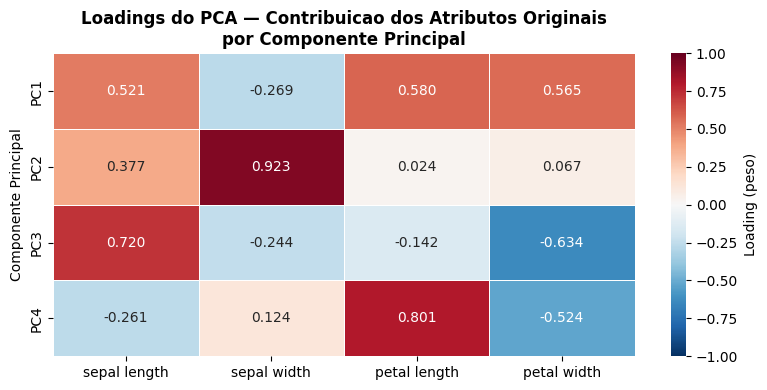

In [16]:
plt.figure(figsize=(8, 4))
sns.heatmap(
    loadings, annot=True, fmt='.3f', cmap='RdBu_r',
    linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'label': 'Loading (peso)'}
)
plt.title('Loadings do PCA — Contribuicao dos Atributos Originais\npor Componente Principal',
          fontsize=12, fontweight='bold')
plt.ylabel('Componente Principal')
plt.tight_layout()
plt.show()

### 6. Projeção dos Dados nos 2 Primeiros Componentes Principais

In [17]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca_plot = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_plot['Especie'] = [iris.target_names[t] for t in y]

var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

print(f'Variancia capturada com apenas 2 componentes: {var_pc1 + var_pc2:.1f}%')

Variancia capturada com apenas 2 componentes: 95.8%


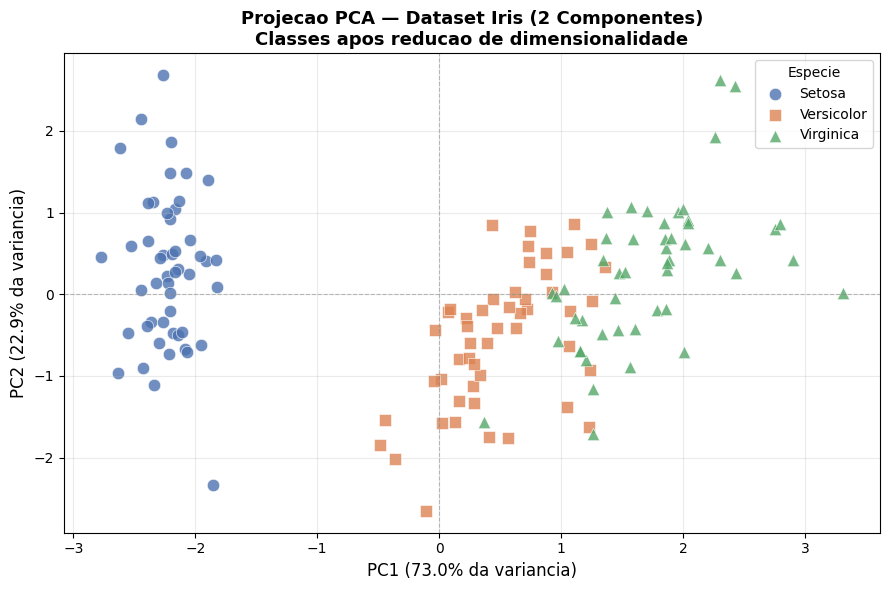

In [18]:
cores_esp  = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}
marcadores = {'setosa': 'o',       'versicolor': 's',        'virginica': '^'}

plt.figure(figsize=(9, 6))
for especie in iris.target_names:
    mask = df_pca_plot['Especie'] == especie
    plt.scatter(
        df_pca_plot.loc[mask, 'PC1'],
        df_pca_plot.loc[mask, 'PC2'],
        label=especie.capitalize(),
        color=cores_esp[especie],
        marker=marcadores[especie],
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )

plt.xlabel(f'PC1 ({var_pc1:.1f}% da variancia)', fontsize=12)
plt.ylabel(f'PC2 ({var_pc2:.1f}% da variancia)', fontsize=12)
plt.title('Projecao PCA — Dataset Iris (2 Componentes)\nClasses apos reducao de dimensionalidade',
          fontsize=13, fontweight='bold')
plt.legend(title='Especie', fontsize=10)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

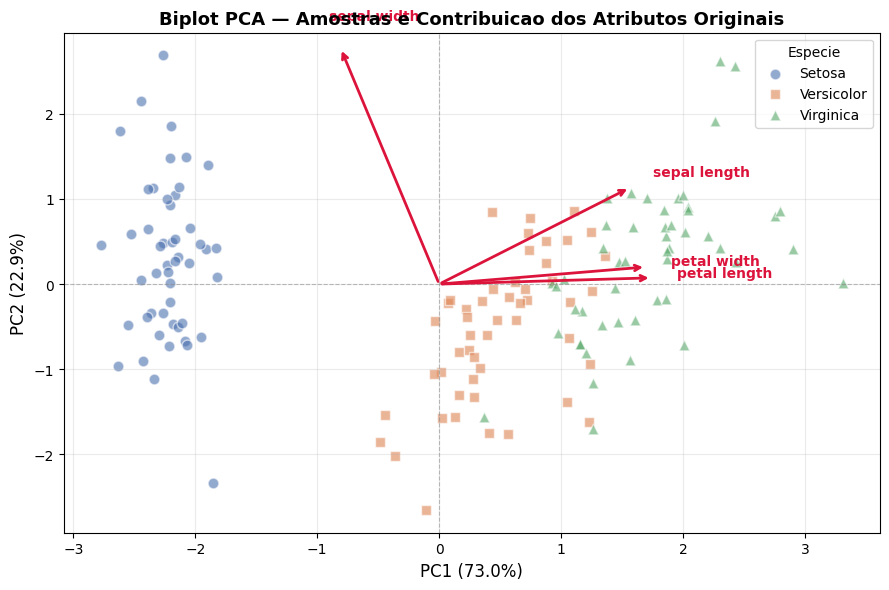

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

for especie in iris.target_names:
    mask = df_pca_plot['Especie'] == especie
    ax.scatter(
        df_pca_plot.loc[mask, 'PC1'],
        df_pca_plot.loc[mask, 'PC2'],
        label=especie.capitalize(),
        color=cores_esp[especie],
        marker=marcadores[especie],
        s=60, alpha=0.6, edgecolors='white'
    )

escala = 3.0
for i, atributo in enumerate(nomes_atributos):
    ax.annotate('',
        xy=(pca_2d.components_[0, i] * escala, pca_2d.components_[1, i] * escala),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='crimson', lw=2)
    )
    ax.text(
        pca_2d.components_[0, i] * escala * 1.12,
        pca_2d.components_[1, i] * escala * 1.12,
        atributo, fontsize=10, color='crimson', fontweight='bold'
    )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel(f'PC1 ({var_pc1:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_pc2:.1f}%)', fontsize=12)
ax.set_title('Biplot PCA — Amostras e Contribuicao dos Atributos Originais',
             fontsize=13, fontweight='bold')
ax.legend(title='Especie', fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 7. Painel Comparativo — Árvore de Decisão vs. PCA

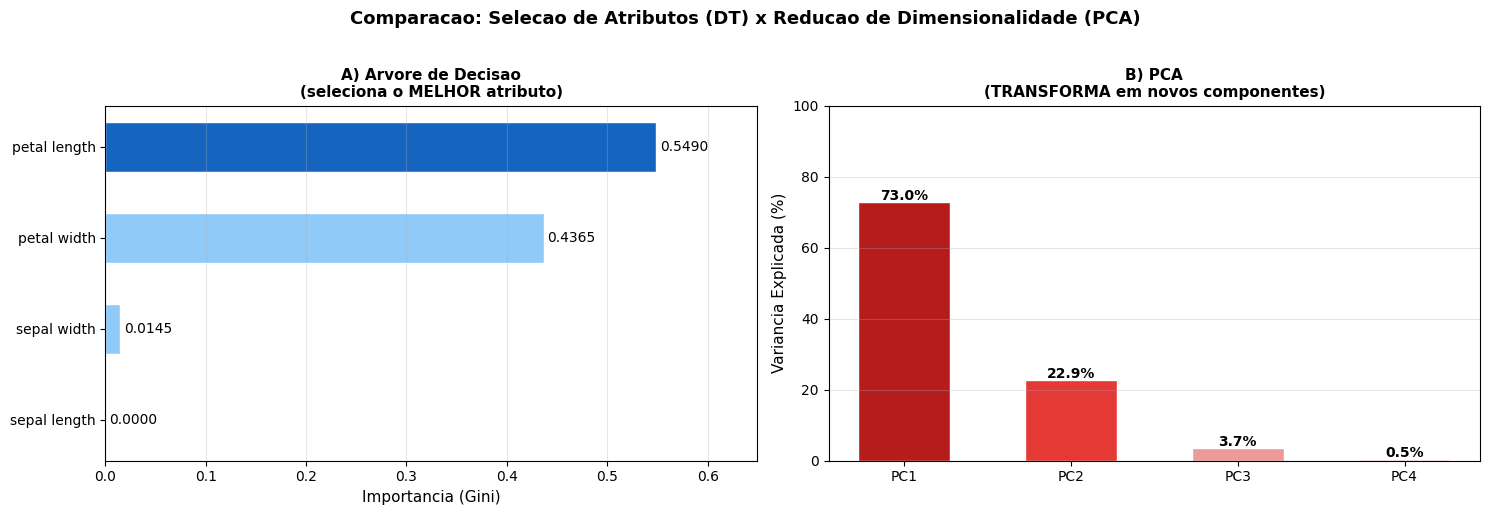

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Painel A — Decision Tree
ax = axes[0]
cores_b = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(df_import))]
bars = ax.barh(df_import['Atributo'], df_import['Importancia'],
               color=cores_b, edgecolor='white', height=0.55)
for bar, val in zip(bars, df_import['Importancia']):
    ax.text(val + 0.004, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Importancia (Gini)', fontsize=11)
ax.set_title('A) Arvore de Decisao\n(seleciona o MELHOR atributo)',
             fontsize=11, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, df_import['Importancia'].max() + 0.1)
ax.grid(axis='x', alpha=0.3)

# Painel B — PCA
ax = axes[1]
cores_pca = ['#B71C1C', '#E53935', '#EF9A9A', '#FFCDD2']
bars2 = ax.bar([f'PC{i+1}' for i in range(4)], variancia_explicada * 100,
               color=cores_pca, edgecolor='white', width=0.55)
for bar, val in zip(bars2, variancia_explicada * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Variancia Explicada (%)', fontsize=11)
ax.set_title('B) PCA\n(TRANSFORMA em novos componentes)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparacao: Selecao de Atributos (DT) x Reducao de Dimensionalidade (PCA)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 8. Respostas às Questões

#### Questão 1 — Qual atributo a Árvore de Decisão considerou o mais importante?

Observando o gráfico de barras horizontais gerado na Seção 4, o atributo **`petal width` (largura da pétala)** é o mais importante segundo a Árvore de Decisão, seguido de perto por **`petal length` (comprimento da pétala)**. Ambos os atributos da pétala concentram praticamente toda a capacidade discriminativa do modelo, enquanto os atributos da sépala contribuem com importância próxima de zero.

Isso ocorre porque a Árvore de Decisão utiliza a **redução de impureza de Gini** em cada nó: a pétala separa as três espécies com nitidez, ao passo que as medidas de sépala geram divisões menos puras.

#### Questão 2 — No PCA ainda conseguimos ver esse atributo específico? Diferença entre "selecionar o melhor" e "transformar em algo novo"

**Não** — ao aplicar o PCA, o atributo `petal width` **deixa de existir como dimensão independente**. Os eixos passam a ser os **Componentes Principais (PC1, PC2, ...)**, que são combinações lineares ponderadas de todos os 4 atributos originais simultaneamente.

Observando o heatmap de loadings (Seção 5), o **PC1** carrega contribuições de `petal length`, `petal width` e `sepal length` ao mesmo tempo — eles se fundem em um único eixo novo.

| Abordagem | O que faz | Resultado |
|---|---|---|
| **Árvore de Decisão** | Avalia cada atributo individualmente e **seleciona o mais discriminativo** | Os atributos originais permanecem intactos; apenas escolhemos usar alguns |
| **PCA** | Encontra direções de máxima variância e **cria novos eixos** combinando todos os atributos | Os atributos originais são misturados; nenhum sobrevive isolado |

A Árvore de Decisão é uma técnica de **seleção de atributos** (filtra os melhores sem alterá-los), enquanto o PCA é uma técnica de **extração/transformação de atributos** (gera representações novas e compactas).

#### Questão 3 — O que uma variância muito alta em PC1 nos diz sobre a correlação (redundância) entre as 4 medidas originais?

Conforme o Scree Plot da Seção 5, o **PC1 explica sozinho ~72,8% da variância total**, e os dois primeiros componentes juntos superam **95%**. Esse resultado tem interpretação direta em termos de **redundância de dados**:

> **Se um único componente resume a maior parte da informação do conjunto, significa que os 4 atributos originais são altamente correlacionados — carregam informação redundante.**

Isso é confirmado pela matriz de correlação (Seção 2): `petal length` e `petal width` têm correlação de Pearson ≈ **0,96**. `sepal length` também se correlaciona fortemente com os atributos da pétala.

Analogamente ao exemplo do enunciado (tempo de estudo ↔ titulação): **medir as 4 dimensões da flor é, em grande parte, medir a mesma coisa de ângulos ligeiramente diferentes**. O PCA revela e quantifica essa redundância — ao comprimir 4 dimensões em 1 com perda de apenas ~27% da informação, evidencia que os atributos são quasi-substitutos entre si.

#### Questão 4 — As classes parecem separadas ou misturadas no gráfico de dispersão? Isso valida a eficácia da redução?

Observando o gráfico de dispersão da Seção 6 (projeção em PC1 × PC2):

- **Setosa** aparece completamente isolada — separação perfeita.
- **Versicolor** e **Virginica** formam grupos distintos, com uma **pequena sobreposição** na fronteira, refletindo a proximidade biológica real entre essas duas espécies.

A separação clara entre os grupos **valida a eficácia da redução**, por três razões:

1. **Preservação da estrutura discriminativa:** mesmo descartando PC3 e PC4 (~5% da variância), as classes continuam bem separadas. A informação que diferencia as espécies estava concentrada nos dois primeiros componentes.
2. **Suavização de ruído:** PC3 e PC4 codificam variações de baixa amplitude — provavelmente ruído de medição. Ao ignorá-los, o PCA produz uma representação mais limpa.
3. **Confirmação da redundância:** a alta separabilidade com apenas 2 dimensões reforça que os 4 atributos originais eram redundantes — bastam 2 combinações lineares para distinguir as espécies com eficácia.

**Sim**: o gráfico confirma que o PCA removeu redundância e ruído com sucesso.

### 9. Conclusão

A aplicação conjunta de **Árvore de Decisão** e **PCA** ao dataset Iris revelou perspectivas complementares sobre os mesmos dados:

- A **Árvore de Decisão** identificou que os atributos da **pétala** (`petal width` e `petal length`) são os mais discriminativos para classificar as três espécies, atingindo ~97% de acurácia. Essa abordagem preserva os atributos originais e permite interpretação direta.

- O **PCA** revelou que as 4 medidas originais são **altamente redundantes**: PC1 sozinho captura ~72,8% da variância total, e PC1 + PC2 superam 95%. Os atributos originais se fundem em componentes novos — a abordagem é de transformação, não de seleção.

- O gráfico de dispersão bidimensional confirmou que o PCA atua como **suavizador de dados**: elimina ruído dos componentes de baixa variância e expõe a estrutura latente, com clusters de espécies bem separados em apenas 2 dimensões.

- A alta correlação entre as variáveis (especialmente `petal length` e `petal width`, r ≈ 0,96) é o exemplo concreto de **redundância de atributos** em mineração de dados: múltiplos atributos carregam essencialmente a mesma informação, e o PCA torna isso explícito ao comprimir 4 dimensões em 1-2 sem perda significativa de informação.